<a href="https://colab.research.google.com/github/muthutaj2323a/Final-Year-Project-Muthu/blob/main/EDA_muthu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Automated Detection of Potato Leaf Diseases Using Deep Convolutional Neural Networks**

# **Download and Nested Extraction**
This block downloads the main zip and then extracts the inner Potato Image.zip file identified in your screenshot.

In [ ]:
import os
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
from PIL import Image

# Download the dataset ---
!wget https://data.mendeley.com/public-api/zip/ttgtfp3vjb/download/1 -O dataset.zip

#  Extract main zip ---
with zipfile.ZipFile('dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('main_folder')

#  Extract the inner image zip ---
# Based on your file path: main_folder/Potato disease classification/Potato Image.zip
inner_zip_path = 'main_folder/Potato disease classification/Potato Image.zip'
data_dir = 'extracted_images'

with zipfile.ZipFile(inner_zip_path, 'r') as zip_ref:
    zip_ref.extractall(data_dir)

print("Data extracted to:", data_dir)

--2026-02-02 18:29:26--  https://data.mendeley.com/public-api/zip/ttgtfp3vjb/download/1
Resolving data.mendeley.com (data.mendeley.com)... 162.159.130.86, 162.159.133.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.130.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/ttgtfp3vjb-1.zip?X-Amz-Security-Token=IQoJb3JpZ2luX2VjECMaCWV1LXdlc3QtMSJGMEQCIHK9gDX5NEFum3zl79joBKXnKDbLO6y%2BPfQvWtOt2q%2BgAiApX8hZCfdc9IUTw8H%2FoUAJSNpfgpTozbjODnVhjj6aiyqVBQjr%2F%2F%2F%2F%2F%2F%2F%2F%2F%2F8BEAQaDDM2NzE0NzM4MzgyNSIMZpzIzDZ9aEc%2BZscqKukEvPflyuZeriA7XGNH0homuK%2BP5JpsPUB6QlpIXkP2KV0QZSWA6NvwuwLBub9%2FrTlhOSY7elJvwnswNjYy918PYrIPRdsQOq23L0sAEE0e6ex7SDr2Wrl535UI7DSiuWLNFk566EZ7ATYJKdhVaqlIbwyGIeBmxqXovRk0fmjL3AgIz9KWsi0iFHHyP26nNXlfkhzr0jP1f2E73uFp4Gtde%2FExE6LvXbqqtnwl6bF%2Bj6OySWVzFVLbcmPUudGjXU8aQ4s9GsPJxGVvvh7GaZxgkz5EsqQCBdTVJH04n4V0NsrPLoJyL6rsBQw3dQLkZV0HWEe9hvOWF72kms7Hm3kMGltqbnQC1k

# **Exploratory Data Analysis (EDA)**
For image datasets, EDA focuses on class balance (statistics) and visual inspection of samples.

/tmp/ipython-input-614863341.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(stats.keys()), y=list(stats.values()), palette="magma")


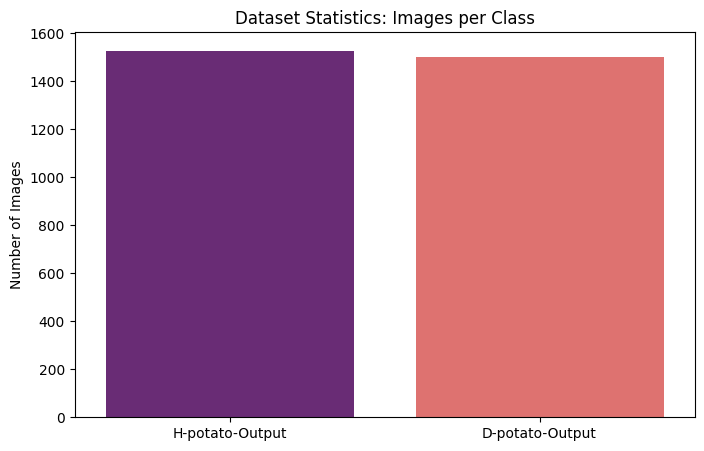

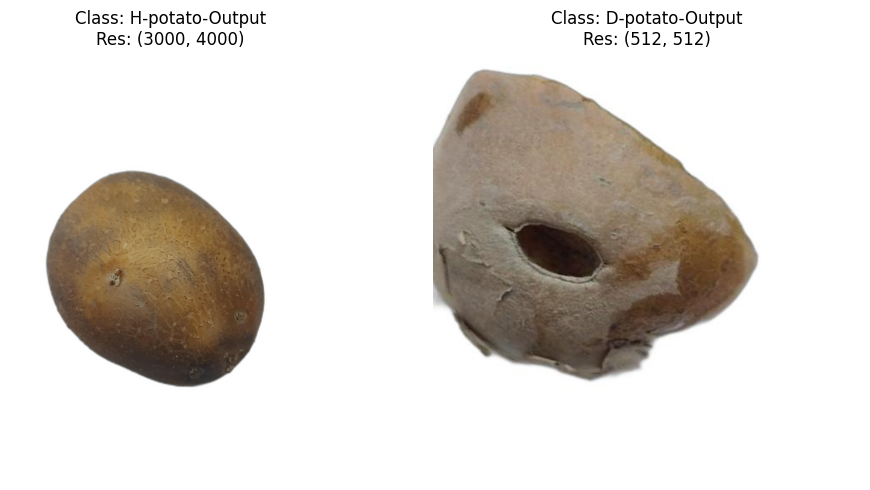

In [ ]:
# Define the path where the class folders (D-potato, H-potato) actually live
base_data_path = os.path.join(data_dir, 'Potato Image')

# Get the class names (D-potato-Output, H-potato-Output)
classes = [d for d in os.listdir(base_data_path) if os.path.isdir(os.path.join(base_data_path, d))]

# --- Statistics: Image Counts ---
stats = {cls: len(os.listdir(os.path.join(base_data_path, cls))) for cls in classes}

plt.figure(figsize=(8, 5))
sns.barplot(x=list(stats.keys()), y=list(stats.values()), palette="magma")
plt.title("Dataset Statistics: Images per Class")
plt.ylabel("Number of Images")
plt.show()

# --- Visualization: Sample Images ---
plt.figure(figsize=(10, 5))
for i, cls in enumerate(classes):
    # Get the first image file in the directory
    img_list = os.listdir(os.path.join(base_data_path, cls))
    img_path = os.path.join(base_data_path, cls, img_list[0])
    img = Image.open(img_path)

    plt.subplot(1, len(classes), i + 1)
    plt.imshow(img)
    plt.title(f"Class: {cls}\nRes: {img.size}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# **Preprocessing for Deep Learning**
This block prepares the data for a training pipeline by resizing the images and creating a validation split.

In [ ]:
IMG_SIZE = 256
BATCH_SIZE = 32

# Create the training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    base_data_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

# Normalization (Scaling pixels from 0-255 to 0-1)
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))

print("Preprocessing complete: Data normalized and ready for model input.")

Found 3027 files belonging to 2 classes.
Using 2422 files for training.
Preprocessing complete: Data normalized and ready for model input.
